# BERDO Analysis

## 1. Project Overview

**Identifying High-Impact Energy Reduction Opportunities in Boston Buildings**

### 1.1 Executive Summary

This report analyzes Boston’s 2025 BERDO building dataset to identify where compliance challenges and energy reduction opportunities are most concentrated. The analysis finds that BERDO compliance is shaped by two distinct challenges: reporting failure and operational performance.
The strongest finding is that missing property type data is not randomly distributed. Buildings with missing classification are heavily concentrated in noncompliant reporting categories, indicating that missing data functions as a structural signal of compliance risk rather than a simple data quality issue.

A second finding is that high Site Energy Use Intensity is concentrated in buildings with greater operational complexity, including manufacturing, laboratory, and other specialized uses. These buildings may be in compliance administratively while still facing significant long-term retrofit difficulty.

These findings suggest that BERDO implementation should not rely on a single intervention strategy. Buildings with missing reporting data require outreach, technical assistance, and ownership coordination support, while high-EUI buildings require deeper retrofit planning, financing pathways, and engineering support.

### 1.2 Tools Used

- Python
  
- pandas
 
- matplotlib

- Excel


### 1.3 Project Objective

This project analyzes BERDO compliance data for Boston buildings to evaluate how energy performance, ownership structure, and building characteristics relate to compliance outcomes.

The goal is to identify where emissions reduction efforts can create the greatest practical impact by distinguishing between buildings that need reporting support and buildings that require deeper retrofit intervention.

Rather than treating all buildings equally, this analysis prioritizes buildings based on energy intensity, operational complexity, and likelihood of compliance barriers.


## 2. Key Insights

### 2.1. Missing Data as a Signal of Compliance Gaps

1,579 buildings across the full dataset fall into the not submitted category. Notably, buildings with missing property type are overwhelmingly concentrated within this group — 1,579 of 1,653 (95.5%) buildings missing a property type are also not submitted, suggesting these two data gaps occur together rather than independently.

### 2.2. BERDO has two intervention groups

- Buildings with missing or incomplete reporting data need outreach, reporting help, and owner coordination.

- Buildings with high Site EUI need deeper energy reduction planning, retrofit support, financing, or technical assistance.

Multifamily is the largest category, but not the biggest reporting challenge. Multifamily Housing has more than 2,000 buildings, making it the largest category in the dataset. But the biggest reporting gap is concentrated in the No Property Type group, not multifamily.

### 2.3. Ownership complexity may help explain reporting gaps

Buildings missing property type are spread across ownership patterns such as LLCs, public sector entities, condominiums, individuals, trusts, and corporate owners. This suggests that reporting gaps may be tied to administrative complexity, fragmented ownership, or limited reporting capacity.

### 2.5. Energy intensity varies more by building function than by building size

Correlation between gross floor area and Site EUI is around 0.099. That means larger buildings are not automatically more energy intensive per square foot.

### 2.6. Specialized buildings show the highest Site EUI

Restaurants, fast food restaurants, healthcare facilities, laboratories, supermarkets, data centers, and industrial uses show some of the highest average Site EUI values. These buildings likely need tailored energy strategies because their energy use is tied to specialized operations.

### 2.7. State pathway buildings have higher average Site EUI

Buildings in the State category show a higher average Site EUI than buildings marked In Compliance. This does not prove causation, but it suggests that some compliance pathways include more energy-intensive buildings.


## 3. Interpretation

These findings show that BERDO compliance challenges are not only about energy performance. They are also about reporting capacity, ownership complexity, and data completeness.

Missing property type is connected to non-submission, suggesting that missing data can serve as an early warning signal for compliance risk. Buildings with incomplete reporting likely need outreach and reporting support, while buildings with high Site EUI may need deeper retrofit planning, technical assistance, or financing.

My analysis supports a phased approach: help incomplete reporters first, and prioritize high-energy buildings for long-term emissions reduction planning.


## 4. Stakeholder Alignment

This pattern aligns with stakeholder interviews conducted with stakeholders.

Common barriers included are difficulty identifying responsible building owners, limited technical capacity among smaller and fragmented ownership groups, complex and time-intensive reporting processes, and limited access to engineering expertise and retrofit planning support

These factors help explain why some buildings submit incomplete data or fail to report entirely.

## 5. Why This Matters

This finding reframes missing data from a limitation into a diagnostic tool.
Missing property type can serve as an early warning signal for buildings at greater risk of noncompliance.

This creates an opportunity to:

• Target outreach and technical assistance more effectively.

• Prioritize buildings with the highest likelihood of reporting gaps.

• Improve compliance through proactive intervention rather than reactive enforcement.


## 6. Final Takeaway

Data completeness and compliance are deeply connected.

In this dataset, missing information is not noise, it is a clear and measurable signal of where the system is breaking down.

There are two different intervention groups:

**Group 1: Not Submitted → needs outreach + reporting support**

**Group 2: High EUI → needs retrofit + energy reduction**


## 7. Methodology

### 7.1 Data Preparation

The analysis uses the 2025 BERDO-reported Energy and Water Metrics dataset for Boston buildings.

Data was imported and cleaned using Python and pandas to improve consistency and analytical usability. Key preprocessing steps included:

1. Standardizing column names for easier querying and analysis.

2. Renaming major variables such as property type, Site EUI, emissions, and compliance status for clarity.

3. Removing records with missing Site EUI values when energy performance comparisons required valid observations.

4. Preserving the full dataset separately for reporting gap and missing data analysis

This allowed the project to distinguish between operational performance analysis and reporting completeness analysis.


### 7.2. Core Variables

The analysis focused on variables most directly connected to BERDO compliance and emissions performance:

• property type

• Site Energy Use Intensity (Site EUI)

• total site energy usage

• greenhouse gas emissions

• compliance status

• building size (gross floor area)

• ownership patterns inferred from owner name classification

These variables were selected to evaluate both energy performance and implementation difficulty.


### 7.3. Analytical Framework

The project combines descriptive analysis, comparative metrics, and rule-based prioritization to identify high-impact intervention groups.

Key methods included:

• compliance distribution analysis across the full dataset

• property type and ownership gap analysis for missing records

• grouped comparison of average Site EUI across compliance categories

• correlation analysis between building size and energy intensity

• complexity classification based on likely retrofit and ownership challenges

• priority segmentation using both energy intensity and implementation complexity

This framework supports a more practical interpretation of BERDO compliance by connecting emissions performance to real implementation barriers.

## 8.0 Data Setup

### 8.1. Libraries

In [31]:
#Load libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### 8.2. File Path

In [ ]:
file_path = Path.home() / "Documents" / "BERDO Analysis" / "2025-reported-energy-and-water-metrics.xlsx"

#Check if the file exists
if not os.path.exists(file_path):
    raise FileNotFoundError("Dataset not found. Please check the file path.")

### 8.3 Table Styling Function

In [32]:
TABLE_STYLES = [
    {"selector": "caption", "props": [
        ("caption-side", "top"), ("font-size", "18px"),
        ("font-weight", "bold"), ("padding", "10px")
    ]},
    {"selector": "th", "props": [
        ("text-align", "center"), ("font-size", "14px"),
        ("font-weight", "bold"), ("padding", "10px"),
        ("border", "1px solid #DADADA")
    ]}
]

def style_table(styler, caption, fmt=None):
    """Apply consistent BERDO table styling."""
    styler = (
        styler
        .hide(axis="index")
        .set_caption(caption)
        .set_properties(**{
            "text-align": "center", "padding": "12px",
            "font-size": "14px", "border": "1px solid #DADADA"
        })
        .set_table_styles(TABLE_STYLES)
    )
    if fmt:
        styler = styler.format(fmt)
    return styler

## 9. Data Loading and Initial Inspection

### 9.1 Load Dataset

In [33]:
def load_dataset(filepath: Path) -> pd.DataFrame:
    """
    Load BERDO dataset with error handling.

    Parameters
    ----------
    filepath : Path
        Path to the Excel file.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.

    Raises
    ------
    FileNotFoundError
        If the file does not exist.
    ValueError
        If the file cannot be read.
    """
    if not filepath.exists():
        raise FileNotFoundError(
            f"Dataset not found at {filepath}. Please check the file path."
        )

    try:
        df = pd.read_excel(filepath, header=0)
        print(f"✓ Dataset loaded successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
        return df
    except Exception as e:
        raise ValueError(f"Error reading Excel file: {e}")

### 9.2 Dataset Overview

In [4]:
#Initial Data Inspection

#Create df before using it
df = load_dataset(file_path)

#Clean column names before renaming them
df.columns = (
    df.columns.str.strip()
    .str.replace("\n", " ", regex=False)
)

#Get dataset dimensions
rows, columns = df.shape

#Dataset overview table
initial_table = pd.DataFrame({
    "Dataset Metric": [
        "Total Records",
        "Total Variables",
        "Missing Values Present"
    ],
    "Result": [
        f"{rows:,}",
        columns,
        "Yes" if df.isnull().sum().sum() > 0 else "No"
    ]
})

display(
    initial_table.style
    .hide(axis="index")
    .set_caption("Dataset Overview")
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

#Preview first 5 rows
display(
    df.head().style
    .hide(axis="index")
    .set_caption("Preview of Raw BERDO Dataset")
    .set_properties(**{
        "text-align": "center",
        "padding": "10px",
        "font-size": "13px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

#Column reference table
column_reference = pd.DataFrame({
    "Column Number": range(1, len(df.columns) + 1),
    "Original Column Name": df.columns.tolist()
})

display(
    column_reference.style
    .hide(axis="index")
    .set_caption("Column Name Reference Guide")
    .set_properties(**{
        "text-align": "left",
        "padding": "10px",
        "font-size": "13px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

✓ Dataset loaded successfully: 5,580 rows, 54 columns


Dataset Metric,Result
Total Records,"5,580"
Total Variables,54
Missing Values Present,Yes


BERDO ID,Tax Parcel ID,Property Owner Name,Building Address,Building Address City,Building Address Zip Code,Parcel Address,Parcel Address City,Parcel Address Zip Code,Reported Gross Floor Area (Sq Ft),Reported Enclosed Parking Area (Sq Ft),BERDO Emissions Gross Floor Area (Sq Ft),Largest Property Type,All Property Types and GFAs,Total Site Energy Usage (kBtu),Energy Star Score,Site EUI (Energy Use Intensity kBtu/ft²),Natural Gas Usage (kBtu),Natural Gas Emissions (kgCO2e),Electricity Usage (kWh),Electricity Emissions (kgCO2e),Renewable System Electricity Usage Onsite (kBtu),District Hot Water Usage (kBtu),District Hot Water Emissions (kgCO2e),District Chilled Water Usage (kBtu),District Chilled Water Emissions (kgCO2e),District Steam Usage (kBtu),District Steam Emissions (kgCO2e),Fuel Oil 1 Usage (kBtu),Fuel Oil 1 Emissions (kgCO2e),Fuel Oil 2 Usage (kBtu),Fuel Oil 2 Emissions (kgCO2e),Fuel Oil 4 Usage (kBtu),Fuel Oil 4 Emissions (kgCO2e),Fuel Oil 5 and 6 Usage (kBtu),Fuel Oil 5 and 6 Emissions (kgCO2e),Propane Usage (kBtu),Propane Emissions (kgCO2e),Diesel Usage (kBtu),Diesel Emissions (kgCO2e),Kerosene Usage (kBtu),Kerosene Emissions (kgCO2e),Water Usage Intensity (Gallons/ft²),Estimated Total GHG Emissions e(kgCO2e),Reporting Compliance Status,First Emissions Compliance Year (Projected),Community Choice Electricity Participation,Renewable Energy Purchased through a Power Purchase Agreement (PPA),Renewable Energy Certificate (REC) Purchase,Backup Generator,Battery Storage,Electric Vehicle (EV) Charging,Corresponding Campus ID,Notes
100001,303060001,1 LOVEJOY WHARF BOSTON REALTY LLC,nan,Boston,2114.000000,160 170 N Washington St,Boston,2114.000000,251688.000000,nan,251688.000000,Office,"Food Sales (15000),Office (231408),Retail Store (5280)",17843015.400000,62.000000,70.900000,4939583.900000,262341.301000,3781779.500000,735783.020000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,10.640000,998124.321000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100002,304794000,10 TEMPLE PLACE LP,2-24 Temple Pl,Boston,2111.000000,24 2 Temple Pl,Boston,2111.000000,135344.000000,nan,135344.000000,Multifamily Housing,"Personal Services (Health/Beauty, Dry Cleaning, etc) (1129),Restaurant (1552),Multifamily Housing (127684),Medical Office (2145),Supermarket/Grocery Store (2834)",7527620.000000,nan,55.600000,4933261.400000,262005.513000,760363.000000,147936.225000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,36.720000,409941.738000,in compliance,2025.000000,Unsure,No,No,Yes,No,No,nan,nan
100003,602757045,10-20 CHANNEL CENTER,20 Channel Center St,Boston,2127.000000,20 30 Channel Center St,Boston,2127.000000,255383.000000,nan,255383.000000,Office,Office (255383),11674291.400000,62.000000,45.700000,nan,nan,3421539.100000,665694.647000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,7.230000,665694.647000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100005,304718000,10-24 SCHOOL STREET,24 School St,Boston,2108.000000,12 Province St,Boston,2108.000000,134789.000000,nan,134789.000000,Office,"Office (108140),Data Center (361),Retail Store (26288)",7580836.800000,82.000000,56.200000,nan,nan,1098218.100000,213669.314000,nan,nan,nan,nan,nan,3833716.600000,226572.651000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,5.360000,440241.965000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100007,304408000,100 HIGH OWNER LLC,100 High St,Boston,2110.000000,100 High St,Boston,2110.000000,551954.000000,94644.000000,646598.000000,Office,"Office (541668),Data Center (400),Other - Restaurant/Bar (9886),Parking (94644)",27164780.800000,79.000000,49.200000,nan,nan,7961541.800000,1548997.573000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,6.430000,1548997.573000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan


Column Number,Original Column Name
1,BERDO ID
2,Tax Parcel ID
3,Property Owner Name
4,Building Address
5,Building Address City
6,Building Address Zip Code
7,Parcel Address
8,Parcel Address City
9,Parcel Address Zip Code
10,Reported Gross Floor Area (Sq Ft)


## 10. Column Renaming and Data Cleaning

### 10.1 Rename Columns

In [5]:
#Rename Columns and Data Cleaning

#Rename important columns for easier analysis
df = df.rename(columns={
    "Largest Property Type": "property_type",
    "Reported Gross Floor Area (Sq Ft)": "gross_floor_area",
    "Site EUI (Energy Use Intensity kBtu/ft²)": "site_eui",
    "Total Site Energy Usage (kBtu)": "total_site_energy",
    "Estimated Total GHG Emissions e(kgCO2e)": "ghg_emissions",
    "Natural Gas Usage (kBtu)": "natural_gas_usage",
    "Electricity Usage (kWh)": "electricity_usage",
    "Reporting Compliance Status": "compliance_status",
    "First Emissions Compliance Year (Projected)": "compliance_year"
})

#Create the full dataset before filtering
df_full = df.copy()

#Filter dataset for valid Site EUI values only
initial_row_count = df_full.shape[0]
df_clean = df_full.dropna(subset=["site_eui"]).copy()
final_row_count = df_clean.shape[0]

#Calculate removed records
rows_removed = initial_row_count - final_row_count
missing_pct = (rows_removed / initial_row_count) * 100

#Create data quality summary table
quality_summary = pd.DataFrame({
    "Data Quality Metric": [
        "Initial Records",
        "Records with Valid Site EUI",
        "Records Removed",
        "Percent Removed"
    ],
    "Result": [
        f"{initial_row_count:,}",
        f"{final_row_count:,}",
        f"{rows_removed:,}",
        f"{missing_pct:.1f}%"
    ]
})

display(
    quality_summary.style
    .hide(axis="index")
    .set_caption("Data Quality Summary")
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

#Preview cleaned dataset
display(
    df_clean[[
        "property_type",
        "site_eui",
        "compliance_status"
    ]].head().style
    .hide(axis="index")
    .set_caption("Preview of Cleaned Analysis Dataset")
    .set_properties(**{
        "text-align": "center",
        "padding": "10px",
        "font-size": "13px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Data Quality Metric,Result
Initial Records,"5,580"
Records with Valid Site EUI,"3,678"
Records Removed,"1,902"
Percent Removed,34.1%


property_type,site_eui,compliance_status
Office,70.900000,in compliance
Multifamily Housing,55.600000,in compliance
Office,45.700000,in compliance
Office,56.200000,in compliance
Office,49.200000,in compliance


### Observation

After cleaning the dataset, the total number of records decreased from 5,580 buildings to 3,678 buildings with valid Site EUI values, meaning 1,902 records (34.1%) were removed due to missing energy intensity data.

This is important because Site EUI serves as one of the strongest indicators of operational energy performance and potential emissions reduction opportunity. Removing records with missing Site EUI improves the reliability of energy performance comparisons by ensuring that grouped analysis is based only on valid observations.

At the same time, preserving the full dataset separately allows reporting gaps and missing-data patterns to be analyzed independently, preventing compliance failures from being hidden during cleaning. This distinction strengthens the overall analysis by separating operational performance problems from reporting completeness problems.

## Analysis

## Features Used
The analysis focuses on variables directly related to compliance and energy performance:
- Property type
- Site Energy Use Intensity (EUI)
- Total energy usage
- Greenhouse gas (GHG) emissions
- Compliance status

## 11. Compliance Distribution

In [6]:
#Compliance Distribution

#Create compliance distribution table
compliance_table = (
    df_full["compliance_status"]
    .value_counts(dropna=False)
    .reset_index()
)

#Rename columns
compliance_table.columns = ["Compliance Status", "Building Count"]

#Calculate percentage distribution
compliance_table["Percent of Buildings"] = (
    compliance_table["Building Count"] /
    compliance_table["Building Count"].sum()
)

#Display styled table
display(style_table(
    compliance_table.style,
    "BERDO Compliance Distribution (2025)",
    {"Building Count": "{:,}", "Percent of Buildings": "{:.1%}"}
))

Compliance Status,Building Count,Percent of Buildings
in compliance,"3,569",64.0%
not submitted,"1,579",28.3%
pending revisions,223,4.0%
state,116,2.1%
nan,93,1.7%


### Observation

The dataset is heavily concentrated in the in compliance category, with 3,569 buildings (64.0%) meeting BERDO reporting requirements. A total of 1,579 buildings fall into the not submitted category, representing a significant portion of Boston's building stock. An additional 93 records have no compliance status recorded and are treated as unknown. Smaller groups include pending revisions (223 buildings, 4.0%) and state pathway compliance (116 buildings, 2.1%).

This distribution shows that while most buildings successfully meet reporting requirements, a substantial group still faces reporting and compliance barriers. These challenges are often concentrated in buildings with fragmented ownership structures, limited technical capacity, or weaker access to engineering and reporting support, particularly among smaller condominium associations, LLC-managed properties, and under-resourced ownership groups.

Rather than representing isolated exceptions, these noncompliant buildings may represent the highest-impact intervention group because they combine both reporting failure and likely future retrofit difficulty. This supports the need for targeted outreach, technical assistance, and proactive compliance support rather than relying only on reactive enforcement.

## 12. Property Type Missing Site EUI Analysis

In [7]:
#property type missing Site EUI analysis

#count all buildings by property type
total_counts = (
    df_full["property_type"]
    .fillna("No Property Type")
    .value_counts()
)

#identify buildings missing Site EUI
missing_eui = df_full[df_full["site_eui"].isna()]

#count missing Site EUI records by property type
missing_eui_counts = (
    missing_eui["property_type"]
    .fillna("No Property Type")
    .value_counts()
)

#combine counts into one table
full_table = pd.DataFrame({
    "Total Buildings": total_counts,
    "Missing Site EUI": missing_eui_counts
}).fillna(0)

#convert columns to integers
full_table["Total Buildings"] = full_table["Total Buildings"].astype(int)
full_table["Missing Site EUI"] = full_table["Missing Site EUI"].astype(int)

#calculate percent missing Site EUI
full_table["Percent Missing Site EUI"] = (
    full_table["Missing Site EUI"] / full_table["Total Buildings"] * 100
).round(1)

#keep top 10 property types by total building count
top10 = full_table.sort_values("Total Buildings", ascending=False).head(10)

#group remaining property types into Other
other_counts = full_table.drop(top10.index)[
    ["Total Buildings", "Missing Site EUI"]
].sum()

other_percent = (
    other_counts["Missing Site EUI"] / other_counts["Total Buildings"] * 100
    if other_counts["Total Buildings"] > 0 else 0
)

other_row = pd.Series({
    "Total Buildings": other_counts["Total Buildings"],
    "Missing Site EUI": other_counts["Missing Site EUI"],
    "Percent Missing Site EUI": round(other_percent, 1)
})

#create final table
property_table = pd.concat([top10, pd.DataFrame(other_row).T])
property_table.index = list(top10.index) + ["Other"]

property_table = (
    property_table
    .reset_index()
    .rename(columns={"index": "Property Type"})
)

#display styled table
display(
    property_table.style
    .hide(axis="index")
    .set_caption("Property Types with Highest Missing Site EUI Rates")
    .format({
        "Total Buildings": "{:,}",
        "Missing Site EUI": "{:,}",
        "Percent Missing Site EUI": "{:.1f}%"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles(TABLE_STYLES)
)

Property Type,Total Buildings,Missing Site EUI,Percent Missing Site EUI
Multifamily Housing,"2,104.0",52.0,2.5%
No Property Type,"1,653.0","1,652.0",99.9%
Office,455.0,30.0,6.6%
College/University,310.0,65.0,21.0%
K-12 School,167.0,4.0,2.4%
Hotel,66.0,0.0,0.0%
Laboratory,50.0,2.0,4.0%
Worship Facility,40.0,3.0,7.5%
Self-Storage Facility,38.0,13.0,34.2%
Vehicle Repair Services,37.0,7.0,18.9%


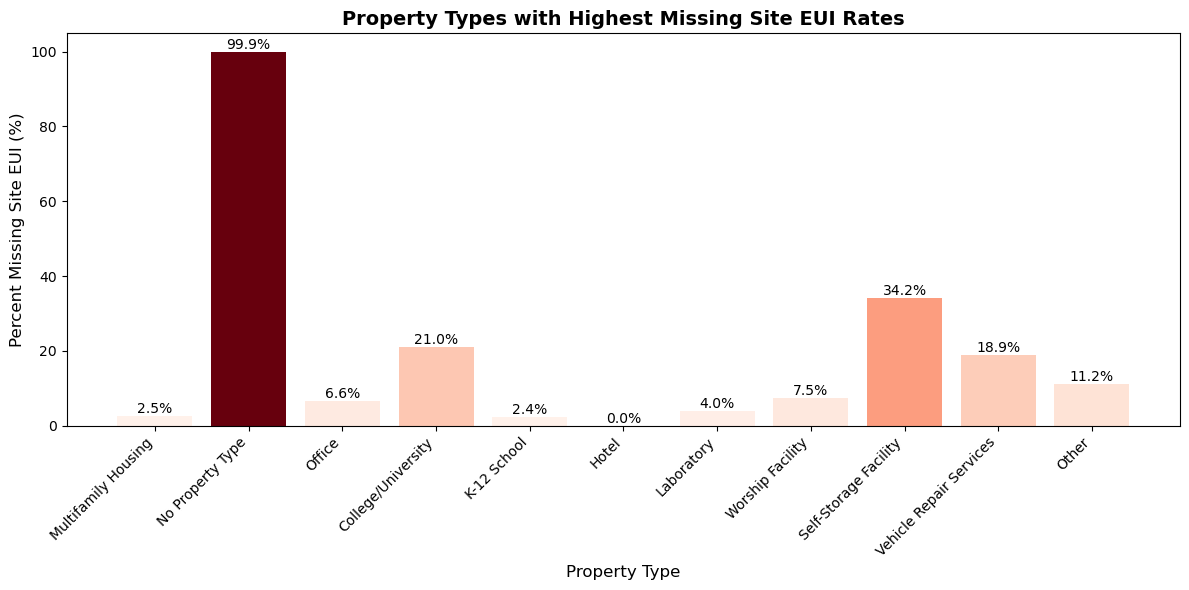

In [8]:
#property type missing Site EUI visualization

#create normalized values for color intensity
values = property_table["Percent Missing Site EUI"]
normalized = values / values.max()

#use Reds colormap for missing data intensity
colors = plt.cm.Reds(normalized)

#create bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    property_table["Property Type"],
    property_table["Percent Missing Site EUI"],
    color=colors
)

plt.title(
    "Property Types with Highest Missing Site EUI Rates",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Property Type", fontsize=12)
plt.ylabel("Percent Missing Site EUI (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")

#add percentage labels above bars
for i, value in enumerate(property_table["Percent Missing Site EUI"]):
    plt.text(
        i,
        value + 0.8,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Observation**

Buildings with missing property type are highly concentrated in records with missing energy performance data. The No Property Type category contains 1,653 total buildings, with 1,652 missing Site EUI, resulting in a 99.9% missing Site EUI rate. By comparison, Multifamily Housing, despite being the largest building category with 2,104 buildings, has only 52 records missing Site EUI.

This shows that missing property classification and missing energy performance data occur together. Missing property type is therefore not simply a data quality issue, but a strong indicator of reporting incompleteness and potential compliance risk.

## 13. Missing Property Type and Compliance Risk

In [9]:
#Buildings Missing Property Type

#Filter buildings with missing property type
missing_property = df_full[df_full["property_type"].isna()].copy()

#Preview key fields for buildings missing property type
display(
    missing_property[[
    "property_type",
    "gross_floor_area",
    "Building Address",
    "Property Owner Name",
    "site_eui",
    "compliance_status"
]]
    .head(20)
    .style
    .hide(axis="index")
    .set_caption("Buildings with Missing Property Type")
    .set_properties(**{
        "text-align": "center",
        "padding": "10px",
        "font-size": "13px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

property_type,gross_floor_area,Building Address,Property Owner Name,site_eui,compliance_status
nan,nan,1047 Commonwealth Ave,1047 COMMONWEALTH PROJECT OWNER LLC,nan,not submitted
nan,nan,1127-1131 Harrison Ave,296 MARLBOROUGH STREET LLC,nan,not submitted
nan,nan,1200 Soldiers Field Rd,1200 SFR LLC,nan,not submitted
nan,nan,1217 Hyde Park Ave,1217 HP REALTY TRUST,nan,not submitted
nan,nan,1246-1250 Massachusetts Ave,1246 MASS AVE LLC,nan,not submitted
nan,nan,1334-1342 Dorchester Ave,1334 DOT LLC,nan,not submitted
nan,nan,138 Harvard Ave,138 HARVARD LLC,nan,not submitted
nan,nan,150 Dorchester Ave,150 DORCHESTER AVENUE,nan,not submitted
nan,nan,152-156 Dudley St,150 DUDLEY LLC,nan,not submitted
nan,nan,152 Hampden St,152 HAMPDEN STREET LLC,nan,not submitted


In [10]:
#Missing EUI by Property Type Availability

#Create indicator for whether property type is missing
df_full["missing_property_type"] = df_full["property_type"].isna()

#Compare missing Site EUI rates by property type availability
result = (
    df_full
    .groupby("missing_property_type")["site_eui"]
    .apply(lambda x: x.isna().mean() * 100)
    .rename("Percent Missing Site EUI")
    .reset_index()
)

#Rename labels for readability
result["missing_property_type"] = result["missing_property_type"].replace({
    False: "Property Type Present",
    True: "Property Type Missing"
})

result = result.rename(columns={
    "missing_property_type": "Property Type Status"
})

#Display formatted table
display(
    result.style
    .hide(axis="index")
    .set_caption("Missing Site EUI by Property Type Availability")
    .format({
        "Percent Missing Site EUI": "{:.1f}%"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Property Type Status,Percent Missing Site EUI
Property Type Present,6.4%
Property Type Missing,99.9%


**Observation** 

Approximately 29.6% of buildings in the dataset lack an assigned property type. Within this group, nearly 100% are also missing energy use data. This indicates that data incompleteness is not randomly distributed, but instead concentrated within a large subset of buildings that are not fully classified. As a result, improving property type classification could significantly increase overall data coverage and reporting completeness.

## 14. Ownership Type Classification

In [11]:
#Classify Ownership Type for Buildings Missing Property Type

owner_col = "Property Owner Name"

#Fill missing owner names to avoid string errors
owner_series = missing_property[owner_col].fillna("").astype(str)

conditions = [

    #1 Property Name or Address-like
    owner_series.str.contains(
        r"^\d+\s+.*\b(?:STREET|ST|AVENUE|AVE|ROAD|RD|BLVD|LANE|LN|DRIVE|DR|COURT|CT|PLACE|PL)\b",
        case=False, na=False
    ),

    #2 Education
    owner_series.str.contains(
        r"SCHOOL|CHARTER|ACADEMY|COLLEGE|UNIVERSITY|EDUCATION",
        case=False, na=False
    ),

    #3 Public Safety
    owner_series.str.contains(
        r"POLICE|FIRE|EMS|PUBLIC SAFETY|PATROLMEN|DEPARTMENT",
        case=False, na=False
    ),

    #4 Condominium
    owner_series.str.contains(
        r"CONDO|CONDOMINIUM",
        case=False, na=False
    ),

    #5 Public Sector
    owner_series.str.contains(
        r"\bCITY\b|\bMASS\b|\bAUTHORITY\b|\bREDEVELOPMENT\b|\bMBTA\b|PUBLIC HEALTH|\bCOMM\b",
        case=False, na=False
    ),

    #6 Trust
    owner_series.str.contains(
        r"TRUST|TRST|\bTS\b",
        case=False, na=False
    ),

    #7 Association
    owner_series.str.contains(
        r"ASSOC|ASSOCIATION",
        case=False, na=False
    ),

    #8 Nonprofit or Religious
    owner_series.str.contains(
        r"CHURCH|FOUNDATION|SOCIETY|COMMUNITY|DIOCESE|METHODIST|BUDDHIST|CATHOLIC|FRIARS|SISTERS|HOLY|PARISH|ARCH|WORSHIP|WRSHP|TEMPLE|MINISTRY",
        case=False, na=False
    ),

    #9 Partnership
    owner_series.str.contains(
        r"\bLLP\b|\bLP\b|\bLPS\b|\bLIMITED PARTNERSHIP\b|\bPARTNERSHIP\b",
        case=False, na=False
    ),

    #10 LLC
    owner_series.str.contains(
        r"\bLLC\b",
        case=False, na=False
    ),

    #11 Corporate
    owner_series.str.contains(
        r"INC|CORP|COMPANY|HOLDINGS|REALTY|PROPERTIES",
        case=False, na=False
    ),

    #12 Business Venture
    owner_series.str.contains(
        r"\bGROUP\b|\bMGMT\b|\bMANAGEMENT\b|\bVENTURES\b|\bCAPITAL\b",
        case=False, na=False
    ),

    #13 Individual
    owner_series.str.contains(
        r"^[A-Za-z]+(?:\s+[A-Za-z\.]+){1,3}$",
        na=False
    )
]

choices = [
    "Property Name",
    "Education",
    "Public Safety",
    "Condominium",
    "Public Sector",
    "Trust",
    "Association",
    "Nonprofit",
    "Partnership",
    "LLC",
    "Corporate",
    "Business Venture",
    "Individual"
]

missing_property["ownership_type"] = np.select(
    conditions,
    choices,
    default="Other"
)

In [12]:
#Ownership Type Summary

#Count ownership type classifications
ownership_counts = (
    missing_property["ownership_type"]
    .fillna("Unclassified")
    .value_counts()
)

#Calculate percentage distribution
ownership_percent = (
    missing_property["ownership_type"]
    .fillna("Unclassified")
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

#Create summary table
ownership_summary = pd.DataFrame({
    "Ownership Type": ownership_counts.index,
    "Count": ownership_counts.values,
    "Percent (%)": ownership_percent.values
})

#Display styled table
display(
    ownership_summary.style
    .hide(axis="index")
    .set_caption("Ownership Type Distribution for Buildings Missing Property Type")
    .format({
        "Count": "{:,}",
        "Percent (%)": "{:.2f}%"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Ownership Type,Count,Percent (%)
LLC,334,20.21%
Public Sector,306,18.51%
Condominium,293,17.73%
Individual,178,10.77%
Trust,118,7.14%
Corporate,115,6.96%
Nonprofit,83,5.02%
Other,63,3.81%
Property Name,61,3.69%
Partnership,50,3.02%


**Observation**

Missing property type information is concentrated among LLC-owned (23.29%), public sector (18.94%), and condominium (18.39%) buildings, which together account for nearly 60% of cases. These ownership structures often involve shared governance, institutional management, or fragmented legal entities, which may contribute to reporting inconsistencies.
While expanded classification reduced the unclassified share, 18.27% of buildings remain categorized as “Other,” reflecting limitations in ownership name standardization and highlighting the challenges of relying on free-text fields for structured analysis.

In [13]:
#Compliance Status by Ownership Type

#Summarize compliance status within each ownership type
compliance_counts = (
    missing_property
    .assign(ownership_type=missing_property["ownership_type"].fillna("Unclassified"))
    .groupby(["ownership_type", "compliance_status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

#Display styled table
display(
    compliance_counts.style
    .hide(axis="index")
    .set_caption("Compliance Status by Ownership Type for Buildings Missing Property Type")
    .format(precision=0)
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

ownership_type,not submitted,pending revisions,state
Association,22,0,0
Business Venture,1,0,0
Condominium,292,1,0
Corporate,115,0,0
Education,27,0,0
Individual,178,0,0
LLC,334,0,0
Nonprofit,83,0,0
Other,55,0,0
Partnership,50,0,0


In [14]:
#Overall Compliance Summary for Buildings Missing Property Type

#Calculate total records across all compliance categories
total = compliance_counts.drop(columns=["ownership_type"]).sum().sum()

#Summarize total counts by compliance category
summary = (
    compliance_counts
    .drop(columns=["ownership_type"])
    .sum(axis=0)
)

#Calculate percentage distribution
percent = (
    summary / total * 100
).round(2)

#Create final summary table
compliance_summary = pd.DataFrame({
    "Compliance Status": summary.index,
    "Count": summary.values,
    "Percent (%)": percent.values
})

#Display styled table
display(
    compliance_summary.style
    .hide(axis="index")
    .set_caption("Overall Compliance Summary for Buildings Missing Property Type")
    .format({
        "Count": "{:,}",
        "Percent (%)": "{:.2f}%"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Compliance Status,Count,Percent (%)
not submitted,"1,579",95.99%
pending revisions,1,0.06%
state,65,3.95%


**Observation**

None of the buildings with missing property type are classified as “In Compliance.”
Instead, the majority fall under “Not Submitted,” with smaller portions in “Pending Revisions” and the “State” pathway.
This suggests that missing property classification is strongly associated with reporting gaps and potential non-compliance, highlighting a key data quality and enforcement issue.

## 15. Property Type and Ownership Distribution Comparison

In [15]:
#Property Type Distribution Comparison

#Overall dataset distribution
overall_percent = (
    df_clean["property_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

#Missing-property subset ownership distribution
missing_percent = (
    missing_property["ownership_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

#Create side-by-side comparison table
comparison = pd.concat(
    [overall_percent, missing_percent],
    axis=1
)

comparison.columns = [
    "All Buildings (%)",
    "Missing Property Type (%)"
]

comparison = (
    comparison
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "Category"})
)

#Display styled table
display(
    comparison.style
    .hide(axis="index")
    .set_caption("Comparison of Overall Property Types vs Missing Property Type Ownership Patterns")
    .format({
        "All Buildings (%)": "{:.2f}%",
        "Missing Property Type (%)": "{:.2f}%"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Category,All Buildings (%),Missing Property Type (%)
Multifamily Housing,55.81%,0.00%
Office,11.56%,0.00%
College/University,6.66%,0.00%
K-12 School,4.43%,0.00%
Hotel,1.79%,0.00%
Laboratory,1.31%,0.00%
Worship Facility,1.01%,0.00%
Fire Station,0.90%,0.00%
Other - Recreation,0.87%,0.00%
Manufacturing/Industrial Plant,0.82%,0.00%


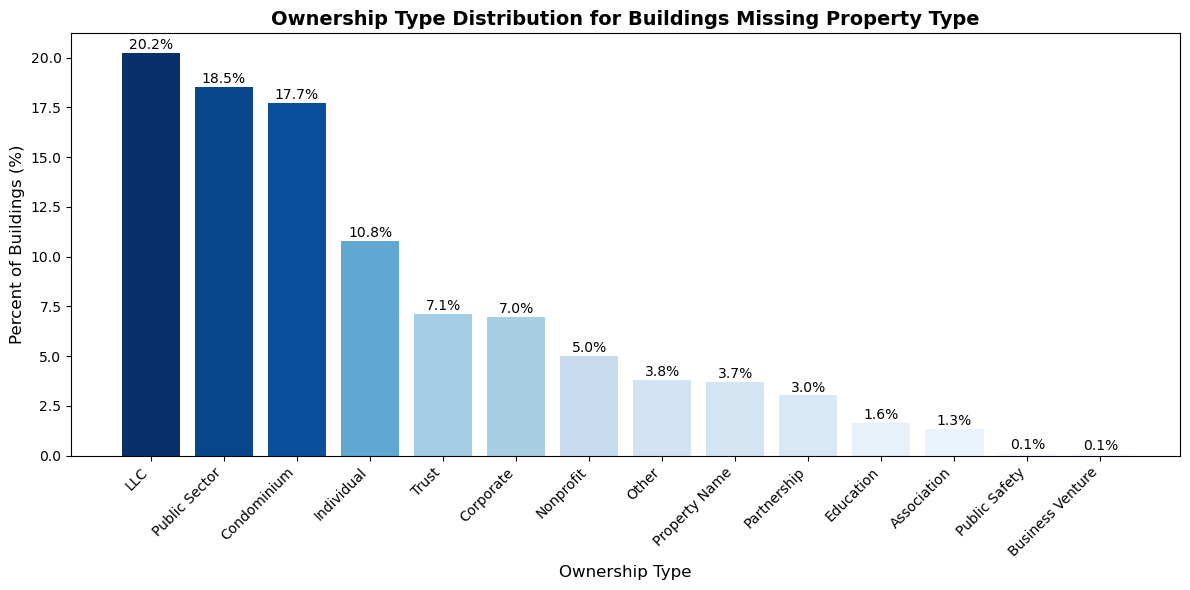

In [16]:
#Ownership Type Distribution Visualization

#Calculate ownership type percentage distribution
ownership_counts = (
    missing_property["ownership_type"]
    .fillna("Unclassified")
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

#Create intensity-based colors using normalized values
values = ownership_counts.values
normalized = values / values.max()

#Use matplotlib Blues colormap for intensity shading
colors = plt.cm.Blues(normalized)

#Create bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    ownership_counts.index,
    ownership_counts.values,
    color=colors
)

plt.title(
    "Ownership Type Distribution for Buildings Missing Property Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Ownership Type",
    fontsize=12
)

plt.ylabel(
    "Percent of Buildings (%)",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

#Add percentage labels above bars
for i, value in enumerate(ownership_counts.values):
    plt.text(
        i,
        value + 0.2,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Observation

While large property types such as multifamily housing and office buildings make up the majority of the building stock and show relatively strong reporting rates. The overall data gap is driven primarily by buildings with no property type classification. Within that missing-property group, LLCs, public sector entities, condominiums, individuals, trusts, and corporate owners make up the largest inferred ownership categories.

This suggests that BERDO compliance challenges are concentrated among smaller, more heterogeneous, and less standardized building types, highlighting the need for targeted outreach and support strategies beyond major building sectors.

## 16. Energy Performance by Compliance Status

In [17]:
#Energy Performance by Compliance Status

#Create cleaned dataset using only buildings with valid Site EUI
df_clean = (
    df_full
    .dropna(subset=["site_eui"])
    .copy()
)

#Calculate average Site EUI by compliance status
eui_by_compliance = (
    df_clean
    .groupby("compliance_status")["site_eui"]
    .mean()
    .rename("Average Site EUI")
    .reset_index()
    .sort_values(
        by="Average Site EUI",
        ascending=False
    )
    .reset_index(drop=True)
)

#Rename column for presentation
eui_by_compliance = eui_by_compliance.rename(columns={
    "compliance_status": "Compliance Status"
})

#Display styled table
display(
    eui_by_compliance.style
    .hide(axis="index")
    .set_caption("Average Site EUI by Compliance Status")
    .format({
        "Average Site EUI": "{:.2f}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Compliance Status,Average Site EUI
state,92.03
in compliance,76.41
pending revisions,73.99


**Observation**

Buildings in the State category had a higher average Site EUI than buildings marked In Compliance.

## 17. Energy Performance by Property Type

In [18]:
#Energy Performance by Property Type

#Calculate average Site EUI by property type
eui_by_type = (
    df_clean
    .groupby("property_type")["site_eui"]
    .mean()
    .rename("Average Site EUI")
    .reset_index()
    .sort_values(
        by="Average Site EUI",
        ascending=False
    )
    .reset_index(drop=True)
)

#Rename column for presentation
eui_by_type = eui_by_type.rename(columns={
    "property_type": "Property Type"
})

#Display styled table
display(
    eui_by_type.style
    .hide(axis="index")
    .set_caption("Average Site EUI by Property Type")
    .format({
        "Average Site EUI": "{:.2f}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Property Type,Average Site EUI
Restaurant,336.85
Fast Food Restaurant,333.50
Zoo,271.90
Urgent Care/Clinic/Other Outpatient,253.67
Hospital (General Medical & Surgical),236.18
Laboratory,233.25
Supermarket/Grocery Store,226.98
Ambulatory Surgical Center,208.35
Other - Technology/Science,196.59
Food Service,171.32


### Observation

Energy use intensity varies significantly by property type. Restaurants, fast food restaurants, healthcare facilities, laboratories, supermarkets, and other specialized uses show some of the highest average Site EUI values. This suggests that building function is a major driver of energy intensity.

## 18. Building Size and Energy Intensity

In [19]:
#Correlation Analysis: Building Size vs Energy Intensity

#Calculate correlation between building size and Site EUI
corr = (
    df_clean[[
        "gross_floor_area",
        "site_eui"
    ]]
    .corr()
    .round(3)
)

#rename columns for cleaner display
corr = corr.rename(
    index={
        "gross_floor_area": "Gross Floor Area",
        "site_eui": "Site EUI"
    },
    columns={
        "gross_floor_area": "Gross Floor Area",
        "site_eui": "Site EUI"
    }
)

#Display styled correlation matrix
display(
    corr.style
    .set_caption("Correlation Matrix: Gross Floor Area vs Site EUI")
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

,Gross Floor Area,Site EUI
Gross Floor Area,1.000000,0.099000
Site EUI,0.099000,1.000000


## 19. Property Type and Compliance Comparison

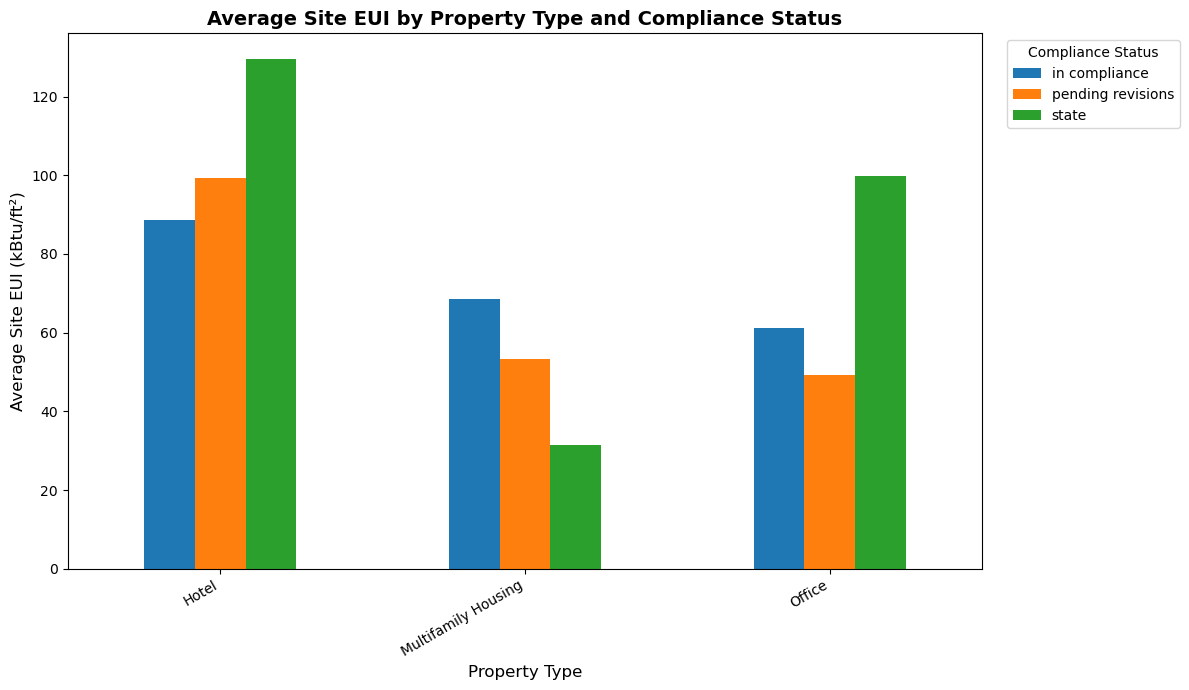

In [20]:
#Average Site EUI by Property Type and Compliance Status

import matplotlib.pyplot as plt

#Remove rows with missing values needed for comparison
df_plot = (
    df_clean
    .dropna(subset=[
        "property_type",
        "compliance_status",
        "site_eui"
    ])
    .copy()
)

#Focus on the top 5 most common property types
top_types = (
    df_plot["property_type"]
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    df_plot[
        df_plot["property_type"].isin(top_types)
    ]
)

#Calculate average Site EUI by property type and compliance status
grouped = (
    df_plot
    .groupby([
        "property_type",
        "compliance_status"
    ])["site_eui"]
    .mean()
    .reset_index()
)

#Create pivot table for grouped bar chart
pivot = grouped.pivot(
    index="property_type",
    columns="compliance_status",
    values="site_eui"
)

#Keep only rows with complete comparisons
pivot = pivot.dropna()

#Sort by highest average EUI using first compliance column
pivot = pivot.sort_values(
    by=pivot.columns[0],
    ascending=False
)

#Create grouped bar chart
ax = pivot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Average Site EUI by Property Type and Compliance Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Property Type",
    fontsize=12
)

plt.ylabel(
    "Average Site EUI (kBtu/ft²)",
    fontsize=12
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Compliance Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 20. Complexity Classification

In [21]:
#Property Type Complexity Classification

#Classify property types into BERDO compliance complexity groups
def classify_complexity(property_type):
    if pd.isna(property_type):
        return "Unknown"

    property_type = property_type.lower()

    #High complexity:
    #Often multifamily or mixed-use buildings with split ownership,
    #limited capital planning, and more difficult retrofit coordination
    if any(x in property_type for x in [
        "multifamily",
        "residential",
        "mixed"
    ]):
        return "High Complexity"

    #Moderate complexity:
    #Common commercial buildings with clearer ownership structure
    #but still meaningful retrofit and compliance challenges
    if any(x in property_type for x in [
        "office",
        "retail",
        "hotel"
    ]):
        return "Moderate Complexity"

    #Low complexity:
    #Large institutional buildings often have stronger capital access,
    #dedicated facilities teams, and structured energy management
    if any(x in property_type for x in [
        "university",
        "hospital",
        "laboratory"
    ]):
        return "Low Complexity"

    #Default classification
    return "Moderate Complexity"

#Apply classification
df_clean["complexity"] = (
    df_clean["property_type"]
    .apply(classify_complexity)
)

## 21. Energy Intensity Classification

In [22]:
#Energy Intensity Classification

#Use median Site EUI as threshold for classification
eui_threshold = df_clean["site_eui"].median()

#Classify buildings into High EUI vs Low EUI
df_clean["eui_category"] = (
    df_clean["site_eui"]
    .apply(
        lambda x:
        "High EUI" if x > eui_threshold
        else "Low EUI"
    )
)

#Display threshold value
threshold_table = pd.DataFrame({
    "Metric": ["Median Site EUI Threshold"],
    "Value": [round(eui_threshold, 2)]
})

display(
    threshold_table.style
    .hide(axis="index")
    .set_caption("Site EUI Classification Threshold")
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Metric,Value
Median Site EUI Threshold,63.300000


**Observation**

Complexity categories were created using a rule-based framework based on likely ownership, retrofit, and operational challenges. These categories are interpretive and should be treated as planning indicators rather than official BERDO classifications.

## 22. Building Segmentation 

In [24]:
#Building Segmentation by Energy Intensity and Complexity

#Create combined building segment using
#energy intensity category and property complexity

df_clean["segment"] = (
    df_clean["eui_category"]
    + " + "
    + df_clean["complexity"]
)

#Preview segment distribution
segment_preview = (
    df_clean["segment"]
    .value_counts()
    .reset_index()
)

segment_preview.columns = [
    "Building Segment",
    "Count"
]

display(
    segment_preview.style
    .hide(axis="index")
    .set_caption("Building Segment Distribution")
    .format({
        "Count": "{:,}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Building Segment,Count
Low EUI + High Complexity,"1,064"
High EUI + High Complexity,"1,003"
Low EUI + Moderate Complexity,663
High EUI + Moderate Complexity,630
High EUI + Low Complexity,201
Low EUI + Low Complexity,116
Low EUI + Unknown,1


## 23. Complexity Scoring

In [25]:
#Numerical Complexity Scoring

#Convert complexity categories into numeric scores
#for comparison and correlation analysis

df_clean["complexity_num"] = (
    df_clean["complexity"]
    .map({
        "Low Complexity": 1,
        "Moderate Complexity": 2,
        "High Complexity": 3
    })
)

#Preview complexity score distribution
complexity_score_summary = (
    df_clean[[
        "complexity",
        "complexity_num"
    ]]
    .drop_duplicates()
    .sort_values("complexity_num")
    .reset_index(drop=True)
)

complexity_score_summary.columns = [
    "Complexity Category",
    "Complexity Score"
]

display(
    complexity_score_summary.style
    .hide(axis="index")
    .set_caption("Complexity Category Scoring System")
    .format({
        "Complexity Score": "{:.0f}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Complexity Category,Complexity Score
Low Complexity,1
Moderate Complexity,2
High Complexity,3
Unknown,nan


## 24. Priority Matrix

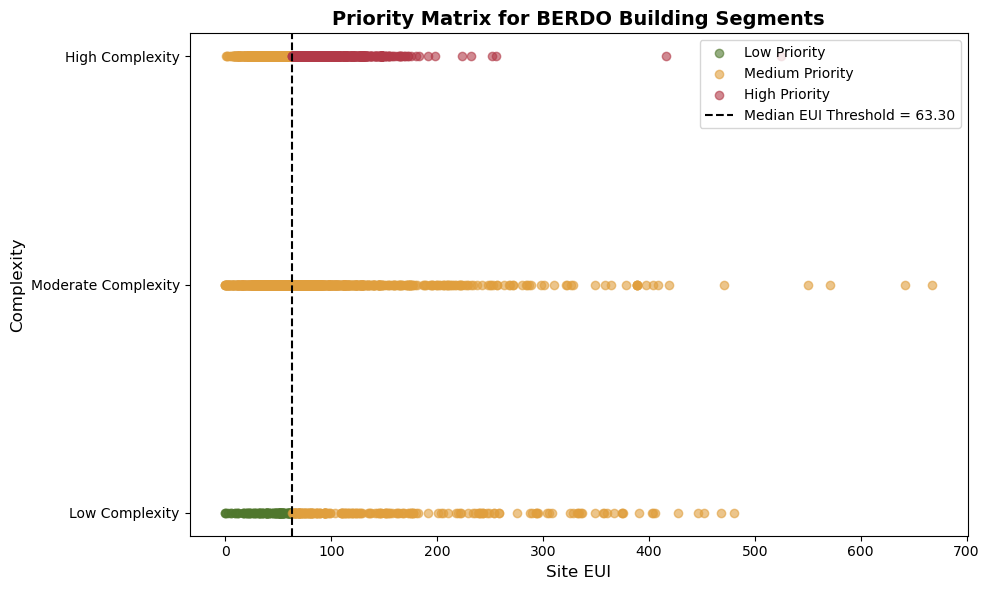

In [26]:
#Priority Matrix

#Create priority column
conditions = [
    (df_clean["site_eui"] >= eui_threshold) & (df_clean["complexity"] == "High Complexity"),
    (df_clean["site_eui"] >= eui_threshold) & (df_clean["complexity"] == "Moderate Complexity"),
    (df_clean["site_eui"] < eui_threshold) & (df_clean["complexity"] == "Low Complexity")
]

choices = [
    "High Priority",
    "Medium Priority",
    "Low Priority"
]

df_clean["priority"] = np.select(
    conditions,
    choices,
    default="Medium Priority"
)

#Numeric mapping for plotting
complexity_map = {
    "Low Complexity": 1,
    "Moderate Complexity": 2,
    "High Complexity": 3
}

#Color mapping
color_map = {
    "High Priority": "#B23A48",
    "Medium Priority": "#E09F3E",
    "Low Priority": "#4F772D"
}

#Create scatter plot
plt.figure(figsize=(10, 6))

for level in ["Low Priority", "Medium Priority", "High Priority"]:
    subset = df_clean[df_clean["priority"] == level]

    plt.scatter(
        subset["site_eui"],
        subset["complexity"].map(complexity_map),
        label=level,
        color=color_map[level],
        alpha=0.6
    )

#Add EUI threshold line
plt.axvline(
    eui_threshold,
    linestyle="--",
    color="black",
    label=f"Median EUI Threshold = {eui_threshold:.2f}"
)

#Axis labels and title
plt.yticks(
    [1, 2, 3],
    ["Low Complexity", "Moderate Complexity", "High Complexity"]
)

plt.xlabel("Site EUI", fontsize=12)
plt.ylabel("Complexity", fontsize=12)
plt.title("Priority Matrix for BERDO Building Segments", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

**Observation**

The average Site EUI across the dataset is substantially lower than the highest-performing outliers, making buildings above 150 strong candidates for priority review. Buildings above 300 represent extreme operational intensity, while values above 500 are likely driven by specialized industrial use or potential reporting anomalies. This supports using tiered thresholds rather than a single fixed cutoff when identifying BERDO compliance priorities.

## 26. BERDO Intervention Type Summary

In [27]:
#High Priority Building Summary

#Count buildings classified as High Priority
high_priority_count = (
    df_clean[
        (df_clean["site_eui"] > eui_threshold) &
        (df_clean["complexity"] == "High Complexity")
    ]
    .shape[0]
)

#Total number of buildings in cleaned dataset
total_buildings = df_clean.shape[0]

#Calculate percentage of total dataset
percent = round(
    high_priority_count / total_buildings * 100,
    2
)

#Create summary table
priority_summary = pd.DataFrame({
    "Metric": [
        "High Priority Buildings",
        "Total Buildings Analyzed",
        "Percent of Dataset"
    ],
    "Value": [
        f"{high_priority_count:,}",
        f"{total_buildings:,}",
        f"{percent:.2f}%"
    ]
})

display(
    priority_summary.style
    .hide(axis="index")
    .set_caption("High Priority Building Summary")
)

Metric,Value
High Priority Buildings,"1,003"
Total Buildings Analyzed,"3,678"
Percent of Dataset,27.27%


In [28]:
#Compliance Status of High Priority Buildings

#Filter high priority buildings
high_priority_buildings = (
    df_clean[
        (df_clean["site_eui"] > eui_threshold) &
        (df_clean["complexity"] == "High Complexity")
    ]
    .copy()
)

#Count compliance status distribution
high_priority_compliance = (
    high_priority_buildings["compliance_status"]
    .value_counts()
    .reset_index()
)

high_priority_compliance.columns = [
    "Compliance Status",
    "Building Count"
]

#Calculate percentage distribution
high_priority_compliance["Percent (%)"] = (
    high_priority_compliance["Building Count"] /
    high_priority_compliance["Building Count"].sum() * 100
).round(2)

#Display styled table
display(
    high_priority_compliance.style
    .hide(axis="index")
    .set_caption("Compliance Status Distribution of High Priority Buildings")
    .format({
        "Building Count": "{:,}",
        "Percent (%)": "{:.2f}%"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Compliance Status,Building Count,Percent (%)
in compliance,968,97.78%
pending revisions,22,2.22%


In [29]:
#Outlier Buildings with Very High Energy Use

#Identify buildings with extremely high Site EUI
#Threshold used: Site EUI > 200

outliers_table = (
    df_clean[
        df_clean["site_eui"] > 200
    ][[
        "Building Address",
        "property_type",
        "gross_floor_area",
        "site_eui",
        "compliance_status"
    ]]
    .sort_values(
        by="site_eui",
        ascending=False
    )
    .reset_index(drop=True)
)

#Rename columns for cleaner presentation
outliers_table = (
    outliers_table.rename(columns={
        "Building Address": "Address",
        "property_type": "Property Type",
        "gross_floor_area": "Gross Floor Area",
        "site_eui": "Site EUI",
        "compliance_status": "Compliance Status"
    })
)

#Display top 20 highest EUI buildings
display(
    outliers_table
    .head(20)
    .style
    .hide(axis="index")
    .set_caption("High-Priority Buildings Requiring Further Review")
    .format({
        "Gross Floor Area": "{:,.0f}",
        "Site EUI": "{:.2f}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "10px",
        "font-size": "13px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #DADADA")
            ]
        }
    ])
)

Address,Property Type,Gross Floor Area,Site EUI,Compliance Status
20 Gillette Park,Manufacturing/Industrial Plant,"1,269,312",667.70,in compliance
941 Massachusetts Ave,Manufacturing/Industrial Plant,"20,837",642.00,in compliance
BEACON ST,Self-Storage Facility,652,571.00,in compliance
306-R Northern Ave,Manufacturing/Industrial Plant,"48,808",550.10,pending revisions
64-70 Monsignor Dennis F. O'Callaghan Way,Multifamily Housing,"3,996",525.00,in compliance
80 N Harvard St,College/University,"25,462",480.00,in compliance
15 Washington St,Supermarket/Grocery Store,"20,350",470.70,in compliance
1 Jimmy Fund Way,Laboratory,"327,824",467.90,in compliance
1 Blackfan Cir,Laboratory,"321,187",452.30,in compliance
250 Longwood Ave,College/University,"91,622",445.80,in compliance


**Observation**

Most of the highest EUI buildings exhibit extremely high energy use intensity (EUI > 200), yet are still classified as “In Compliance,” indicating that compliance status is not solely determined by energy intensity. Notably, some of these outliers are relatively small buildings, suggesting potential data anomalies or atypical usage patterns. 

The presence of high-energy outliers within the “Other” category reinforces the complexity and heterogeneity of this group, which may obscure important variations in building performance.

## BERDO Intervention Type Summary

This section translates the analysis into practical intervention categories. Buildings with missing property type or missing Site EUI are classified as needing reporting support. Buildings with valid data and above-median Site EUI are classified as needing retrofit planning. Buildings with complete data and lower Site EUI are classified as monitor.

In [30]:
#classify buildings by likely intervention need
def classify_intervention(row):
    if pd.isna(row["property_type"]) or pd.isna(row["site_eui"]):
        return "Reporting Support"
    elif row["site_eui"] >= eui_threshold:
        return "Retrofit Planning"
    else:
        return "Monitor"

df_full["intervention_type"] = df_full.apply(classify_intervention, axis=1)

#summarize intervention groups
intervention_summary = (
    df_full["intervention_type"]
    .value_counts()
    .reset_index()
)

intervention_summary.columns = [
    "Intervention Type",
    "Building Count"
]

intervention_summary["Percent of Buildings"] = (
    intervention_summary["Building Count"] /
    intervention_summary["Building Count"].sum()
)

display(
    intervention_summary.style
    .hide(axis="index")
    .set_caption("BERDO Intervention Type Summary")
    .format({
        "Building Count": "{:,}",
        "Percent of Buildings": "{:.1%}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "14px",
        "border": "1px solid #DADADA"
    })
    .set_table_styles(TABLE_STYLES)
)

Intervention Type,Building Count,Percent of Buildings
Reporting Support,"1,903",34.1%
Retrofit Planning,"1,840",33.0%
Monitor,"1,837",32.9%


**Observation**

The results show that BERDO implementation requires more than one strategy. One-third of buildings need reporting support, one-third may need deeper retrofit planning, and one-third can be monitored. This supports a phased approach that first addresses incomplete reporting, then prioritizes high-energy buildings for long-term emissions reduction planning.

## Conclusion

This analysis reveals that BERDO compliance is shaped by two distinct but connected challenges: reporting failure and building performance.

The first challenge is data completeness. A significant portion of buildings fail to submit required information entirely, and this is strongly associated with missing property classification. Buildings without an assigned property type are not randomly distributed across the dataset—they are overwhelmingly concentrated in noncompliant reporting categories, particularly “Not Submitted.” This shows that missing data is not simply a technical issue, but a structural indicator of compliance risk. These gaps are most commonly linked to fragmented ownership structures such as condominiums, LLCs, and certain public or institutional properties, where coordination, accountability, and access to technical support are often more difficult.

The second challenge is operational performance. Among buildings that do report, Site Energy Use Intensity varies significantly across property types. Restaurants, healthcare facilities, laboratories, supermarkets, industrial buildings, and other specialized uses show some of the highest average Site EUI values. These buildings face a different type of compliance pressure: not necessarily reporting failure, but deeper operational and retrofit complexity.

This creates two separate intervention groups. The first group includes buildings that need outreach, reporting assistance, and ownership coordination support. The second includes buildings that require long-term retrofit planning, financing pathways, and technical decarbonization strategies. Treating both groups the same would overlook the very different barriers they face.

The most important finding is that compliance outcomes and data availability are not evenly distributed across Boston’s building stock. Larger and more standardized building types, such as multifamily housing and office buildings, generally show stronger reporting consistency, while the broad “Other” category and buildings with missing classifications contribute disproportionately to reporting gaps and reduced policy visibility.

Achieving meaningful emissions reductions under BERDO will require more than targeting high-energy buildings alone. It will require improving data completeness, reducing reporting friction, and supporting under-resourced ownership groups that struggle to engage with compliance systems. Expanding technical assistance, simplifying reporting pathways, and using missing data as an early warning signal can help shift BERDO from reactive enforcement toward proactive intervention.

The primary barrier to effective climate policy implementation in this context is not only energy performance, but data visibility and ownership structure, which shape how buildings engage with and comply with BERDO requirements.

## What I Learned

The concentration of missing property type data among “Not Submitted” buildings is not random, but reflects deeper structural barriers to BERDO compliance. Through both quantitative analysis and stakeholder interviews, it became clear that missing data often signals broader ownership and coordination challenges rather than simple reporting mistakes.

Smaller and more fragmented ownership groups, particularly condominiums, LLC-managed properties, and certain public or institutional buildings, often face difficulty identifying who is responsible for compliance, securing access to engineering expertise, and managing the time-intensive reporting process. Many lack dedicated facilities staff, long-term capital planning systems, or clear decision-making structures, which makes both reporting and retrofit planning significantly more difficult.
This helped shift my understanding of compliance from a purely technical issue to an operational and organizational one. Buildings that fail to report are often the same buildings lacking the internal capacity to engage with BERDO requirements in the first place.

As a result, missing property type data should not be treated simply as a limitation in the dataset. It functions as a measurable indicator of compliance risk and highlights where policy support, technical assistance, and targeted outreach are most needed. This reinforced the importance of using data not only to measure outcomes, but also to identify where the system itself is creating barriers to participation.